# SVR Regression for Crop Yield Prediction

This notebook implements a Support Vector Regression (SVR) model
for predicting crop yield.

The workflow includes:
- Dataset loading
- Data cleaning
- Missing-value handling
- Duplicate removal
- Feature and target separation
- Train-test split
- Data preprocessing
- SVR model training
- Prediction
- Model evaluation using MAE, MSE, RMSE and R²
- Actual vs Predicted visualization
- Residual analysis
- Model saving

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv(
    r"C:\Crop Yield Prediction\data\Crop Yield Data.csv"
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (19689, 13)


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [5]:
print("========== MISSING VALUE ANALYSIS ==========")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

========== MISSING VALUE ANALYSIS ==========
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    2
Fertilizer         2
Pesticide          2
Yield              1
Avg_Temperature    2
Max_Temperature    0
Min_Temperature    0
dtype: int64

Total missing values: 9


In [6]:
print(
    "Missing Yield values before removal:",
    df["Yield"].isnull().sum()
)

df = df.dropna(
    subset=["Yield"]
).reset_index(drop=True)

print(
    "Missing Yield values after removal:",
    df["Yield"].isnull().sum()
)

print(
    "Dataset shape after removing missing Yield:",
    df.shape
)

Missing Yield values before removal: 1
Missing Yield values after removal: 0
Dataset shape after removing missing Yield: (19688, 13)


In [7]:
duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate records:",
    duplicate_count
)

df = df.drop_duplicates().reset_index(drop=True)

print(
    "Shape after duplicate removal:",
    df.shape
)

Number of duplicate records: 0
Shape after duplicate removal: (19688, 13)


duplicate_count = df.duplicated().sum()

print(
    "Number of duplicate records:",
    duplicate_count
)

df = df.drop_duplicates().reset_index(drop=True)

print(
    "Shape after duplicate removal:",
    df.shape
)

In [8]:
X = df.drop(
    ["Yield", "Production"],
    axis=1
)

y = df["Yield"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures used for SVR:")
print(X.columns.tolist())

Features shape: (19688, 11)
Target shape: (19688,)

Features used for SVR:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


In [9]:
print(
    "Missing values in target:",
    y.isnull().sum()
)

if y.isnull().sum() == 0:
    print("Target variable is ready for model training.")
else:
    print("Warning: Target still contains missing values.")

Missing values in target: 0
Target variable is ready for model training.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("========== TRAIN-TEST SPLIT ==========")

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

========== TRAIN-TEST SPLIT ==========
Training data shape: (15750, 11)
Testing data shape: (3938, 11)
Training target shape: (15750,)
Testing target shape: (3938,)


In [11]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("========== FEATURE TYPES ==========")

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

========== FEATURE TYPES ==========
Numerical Features:
['Crop_Year', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']

Categorical Features:
['Crop', 'Season', 'State']


C:\Users\Manisha\AppData\Local\Temp\ipykernel_17936\1339560515.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [12]:
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created!")

Numerical preprocessing pipeline created!


In [13]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created!")

Categorical preprocessing pipeline created!


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [15]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Training data processed successfully!")
print("Testing data processed successfully!")

print(
    "\nProcessed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Training data processed successfully!
Testing data processed successfully!

Processed training shape: (15750, 99)
Processed testing shape: (3938, 99)


## Support Vector Regression (SVR)

Support Vector Regression (SVR) is a supervised machine learning
algorithm used for regression problems.

For the baseline SVR model, the following parameters are used:

- Kernel = RBF
- C = 100
- Gamma = scale
- Epsilon = 0.1

The RBF kernel is used to capture non-linear relationships between
the input features and crop yield.

In [16]:
svr_model = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

print("SVR model created successfully!")

SVR model created successfully!


In [17]:
print("Starting SVR training...")

svr_model.fit(
    X_train_processed,
    y_train
)

print("SVR model trained successfully!")

Starting SVR training...


SVR model trained successfully!


In [26]:
svr_predictions = svr_model.predict(
    X_test_processed
)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(svr_predictions[:10])

Predictions generated successfully!

First 10 predictions:
[ 0.08023396  0.21103469 13.0612528   0.98958429  0.76669857  0.16782485
  1.22854867  0.68062525 65.51740539  0.63788382]


In [27]:
svr_mae = mean_absolute_error(
    y_test,
    svr_predictions
)

svr_mse = mean_squared_error(
    y_test,
    svr_predictions
)

svr_rmse = np.sqrt(svr_mse)

svr_r2 = r2_score(
    y_test,
    svr_predictions
)

print("========== SVR RESULTS ==========")

print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R²  :", svr_r2)

========== SVR RESULTS ==========
MAE : 60.80751243054028
MSE : 553774.2173311898
RMSE: 744.1600750720169
R²  : 0.2162589279637923


In [28]:
svr_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "SVR": [
        svr_mae,
        svr_mse,
        svr_rmse,
        svr_r2
    ]
})

svr_results

,Metric,SVR
0,MAE,60.807512
1,MSE,553774.217331
2,RMSE,744.160075
3,R²,0.216259


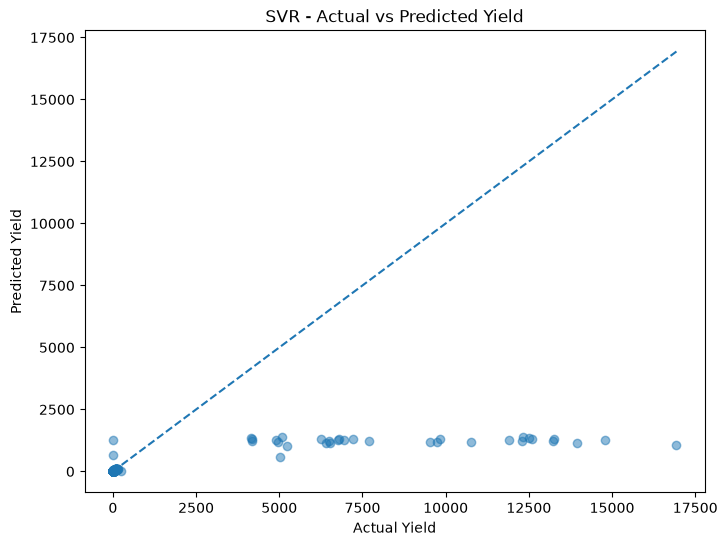

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    svr_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    svr_predictions.min()
)

max_value = max(
    y_test.max(),
    svr_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("SVR - Actual vs Predicted Yield")

plt.show()

In [30]:
svr_residuals = y_test - svr_predictions

print("========== RESIDUAL STATISTICS ==========")

print(
    pd.Series(svr_residuals).describe()
)

========== RESIDUAL STATISTICS ==========
count     3938.000000
mean        59.079807
std        741.905362
min      -1266.386573
25%         -0.176084
50%          0.001321
75%          0.169966
max      15861.789475
Name: Yield, dtype: float64


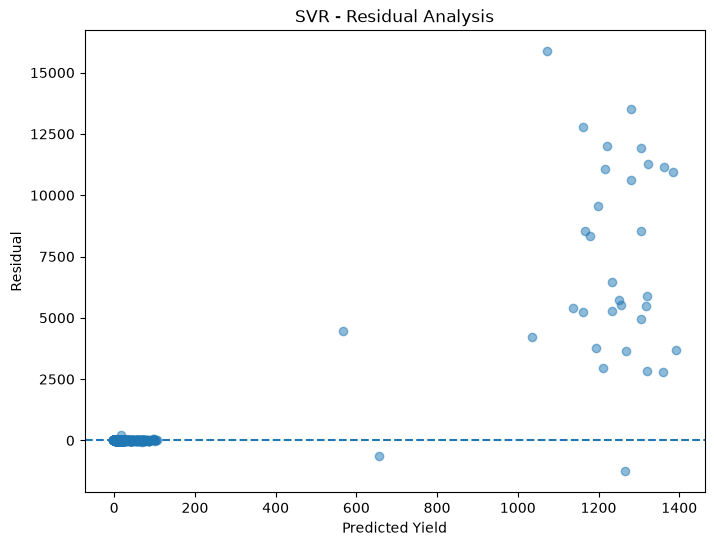

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    svr_predictions,
    svr_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title("SVR - Residual Analysis")

plt.show()

In [24]:
joblib.dump(
    svr_model,
    r"C:\Crop Yield Prediction\models\svr_model.pkl"
)

print("SVR model saved successfully!")

SVR model saved successfully!


In [25]:
joblib.dump(
    preprocessor,
    r"C:\Crop Yield Prediction\models\svr_preprocessor.pkl"
)

print("SVR preprocessor saved successfully!")

SVR preprocessor saved successfully!


## SVR Model Conclusion

The Support Vector Regression (SVR) model was successfully trained
to predict crop yield using agricultural, environmental, crop,
season and state features.

The model was evaluated using MAE, MSE, RMSE and R².

An Actual-versus-Predicted plot and residual analysis were performed
to examine prediction performance and prediction errors.

The trained SVR model and preprocessing pipeline were saved for
future use.

The obtained SVR results will be compared with Random Forest and
XGBoost in the model comparison stage.